In [226]:
!pip install shap

In [227]:
# 1. Data Manipulation
import pandas as pd
import numpy as np

# 2. Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# 3. Preprocessing & Modeling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# 4. Evaluation & Explainability
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import shap

# Data Loading

In [228]:
! gdown 1IUnGuNxvm-Lk0g67Iwa6Qz1QOgvA8XJp

Downloading...
From: https://drive.google.com/uc?id=1IUnGuNxvm-Lk0g67Iwa6Qz1QOgvA8XJp
To: /content/HumanResources.csv
100% 1.19M/1.19M [00:00<00:00, 81.4MB/s]


In [229]:
df = pd.read_csv('/content/HumanResources.csv')
df.head()

,employee_id,first_name,last_name,gender,state,city,hiredate,department,job_title,education_level,salary,performance_rating,overtime,birthdate,termdate
0,00-95822412,Danielle,Johnson,Male,Pennsylvania,Allentown,2016-04-10,Sales,Sales Consultant,Bachelor,106044,Good,No,1981-11-27,2024-03-10
1,00-46913810,Jeffrey,Doyle,Male,Florida,Miami,2017-09-04,Sales,Sales Representative,Bachelor,65844,Satisfactory,No,1983-07-07,2019-06-02
2,00-28728463,Patricia,Miller,Male,New York,Rochester,2022-06-03,Marketing,Content Creator,High School,61316,Good,No,1973-11-03,2023-09-29
3,00-83197857,Anthony,Robinson,Male,New York,New York City,2016-07-03,Customer Service,Help Desk Technician,Bachelor,90515,Satisfactory,No,1989-10-08,2023-10-25
4,00-66629388,Anthony,Gonzalez,Male,New York,New York City,2015-08-25,IT,System Administrator,Master,65570,Good,No,1977-06-17,2021-05-09


In [230]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   employee_id         8950 non-null   object
 1   first_name          8950 non-null   object
 2   last_name           8950 non-null   object
 3   gender              8950 non-null   object
 4   state               8950 non-null   object
 5   city                8950 non-null   object
 6   hiredate            8950 non-null   object
 7   department          8950 non-null   object
 8   job_title           8950 non-null   object
 9   education_level     8950 non-null   object
 10  salary              8950 non-null   int64 
 11  performance_rating  8950 non-null   object
 12  overtime            8950 non-null   object
 13  birthdate           8950 non-null   object
 14  termdate            1000 non-null   object
dtypes: int64(1), object(14)
memory usage: 1.0+ MB


# Data Preprocessing & Feature Engineering

In [231]:
def check_data_quality(df_input):
    # 1. Check for duplicate rows
    duplicates = df_input.duplicated().sum()

    # 2. Check for missing values
    missing_values = df_input.isnull().sum()
    missing_pct = (df_input.isnull().sum() / len(df_input)) * 100

    # Create a summary report
    quality_report = pd.DataFrame({
        'Missing Values': missing_values,
        'Percentage (%)': missing_pct.round(2)
    })

    print(f"Number of duplicate rows: {duplicates}")
    print("\nMissing Values Statistics:")
    return quality_report

# Run quality check on the original dataframe
check_data_quality(df)

Number of duplicate rows: 0

Missing Values Statistics:


,Missing Values,Percentage (%)
employee_id,0,0.00
first_name,0,0.00
last_name,0,0.00
gender,0,0.00
state,0,0.00
city,0,0.00
hiredate,0,0.00
department,0,0.00
job_title,0,0.00
education_level,0,0.00


Data Quality:

- Duplicates: No duplicate rows were detected in the dataset, ensuring data integrity.

- Missing Values: * Most columns are fully populated with 0% missing values.

  - The termdate column contains 7,950 missing values (88.83%). This is expected in HR analytics, as these null values represent active employees who have not yet reached a termination date.

In [232]:
# 1. Convert date columns to datetime format
date_columns = ['hiredate', 'termdate', 'birthdate']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# 2. Create target variable: attrition (1 if termdate exists, else 0)
df['attrition'] = df['termdate'].notna().astype(int)

# 3. Calculate Age and Tenure
current_date = pd.Timestamp.today().normalize()
df['end_date'] = df['termdate'].fillna(current_date)

df['age'] = (df['end_date'] - df['birthdate']).dt.days / 365.25
df['tenure_years'] = (df['end_date'] - df['hiredate']).dt.days / 365.25


# Exploratory Data Analysis (EDA)

In [233]:
# 1. Define columns to drop for EDA
cols_to_drop = [
    'employee_id', 'first_name', 'last_name',
    'hiredate', 'termdate', 'birthdate', 'end_date'
]

# 2. Create the EDA dataframe
df_eda = df.drop(columns=cols_to_drop)

# 3. Check final EDA dataset
print("EDA Dataset Shape:", df_eda.shape)
print("\nAvailable Columns:", df_eda.columns.tolist())
display(df_eda.head())

EDA Dataset Shape: (8950, 12)

Available Columns: ['gender', 'state', 'city', 'department', 'job_title', 'education_level', 'salary', 'performance_rating', 'overtime', 'attrition', 'age', 'tenure_years']


,gender,state,city,department,job_title,education_level,salary,performance_rating,overtime,attrition,age,tenure_years
0,Male,Pennsylvania,Allentown,Sales,Sales Consultant,Bachelor,106044,Good,No,1,42.283368,7.915127
1,Male,Florida,Miami,Sales,Sales Representative,Bachelor,65844,Satisfactory,No,1,35.904175,1.741273
2,Male,New York,Rochester,Marketing,Content Creator,High School,61316,Good,No,1,49.902806,1.322382
3,Male,New York,New York City,Customer Service,Help Desk Technician,Bachelor,90515,Satisfactory,No,1,34.045175,7.310062
4,Male,New York,New York City,IT,System Administrator,Master,65570,Good,No,1,43.893224,5.705681


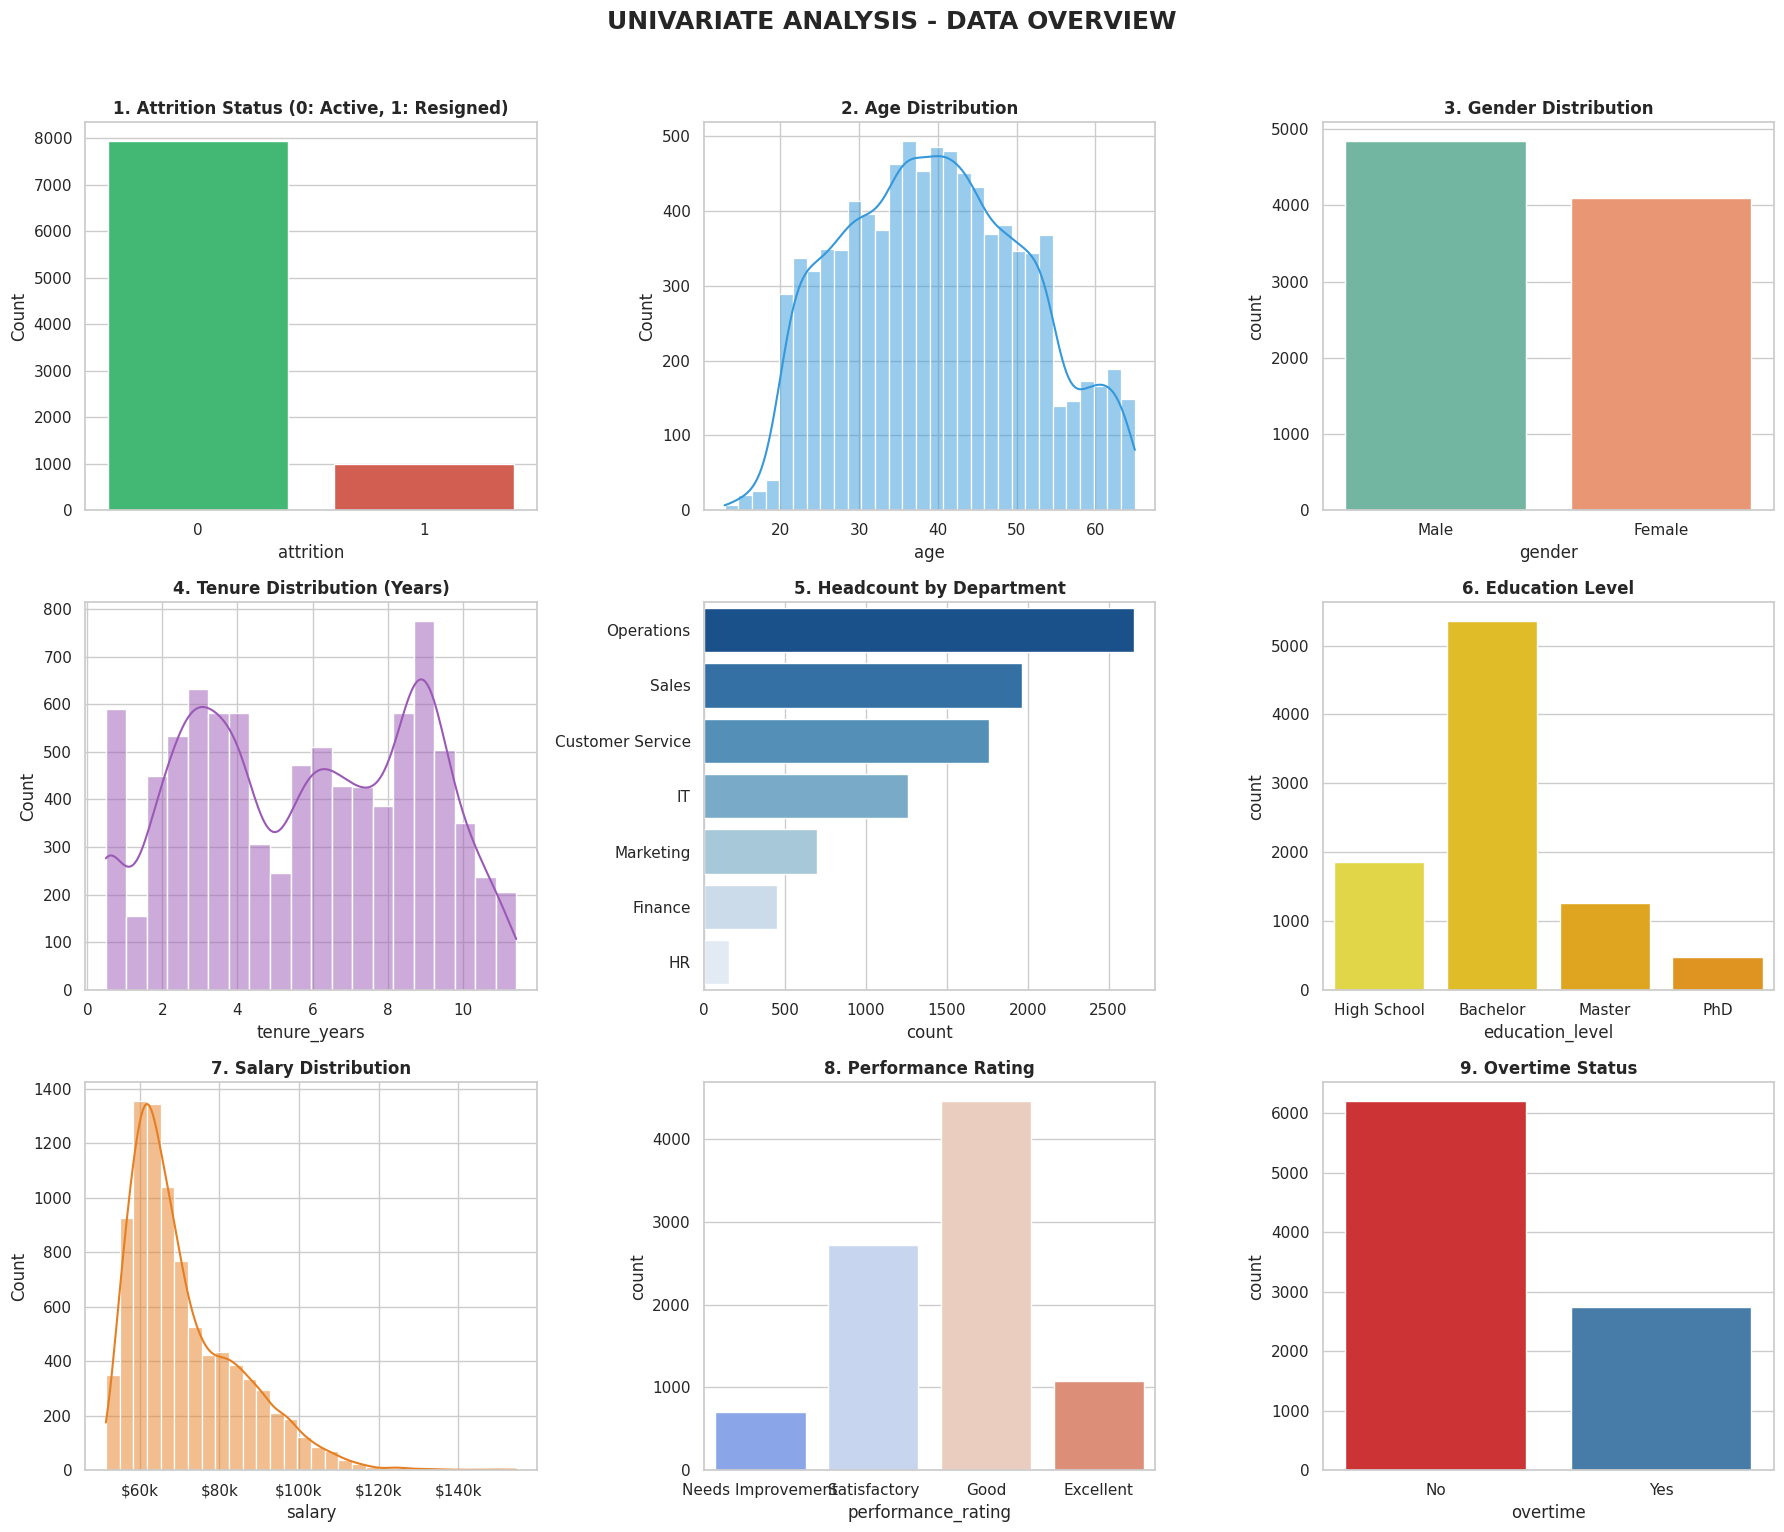

In [234]:

# Set professional plot style
sns.set_theme(style="whitegrid")

# Create a 3x3 grid for plots (using 9 subplots)
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
fig.suptitle('UNIVARIATE ANALYSIS - DATA OVERVIEW', fontsize=18, fontweight='bold', y=1.02)

# ==========================================
# ROW 1: TARGET VARIABLE & BASIC DEMOGRAPHICS
# ==========================================

# 1. Attrition (Target Variable)
sns.countplot(data=df_eda, x='attrition', ax=axes[0, 0], palette=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('1. Attrition Status (0: Active, 1: Resigned)', fontweight='bold')
axes[0, 0].set_ylabel('Count')

# 2. Age Distribution
sns.histplot(data=df_eda, x='age', bins=30, kde=True, ax=axes[0, 1], color='#3498db')
axes[0, 1].set_title('2. Age Distribution', fontweight='bold')

# 3. Gender Ratio
sns.countplot(data=df_eda, x='gender', ax=axes[0, 2], palette='Set2')
axes[0, 2].set_title('3. Gender Distribution', fontweight='bold')

# ==========================================
# ROW 2: JOB INFORMATION & TENURE
# ==========================================

# 4. Tenure Distribution (Years)
sns.histplot(data=df_eda, x='tenure_years', bins=20, kde=True, ax=axes[1, 0], color='#9b59b6')
axes[1, 0].set_title('4. Tenure Distribution (Years)', fontweight='bold')

# 5. Headcount by Department
sns.countplot(data=df_eda, y='department', ax=axes[1, 1], palette='Blues_r', order=df_eda['department'].value_counts().index)
axes[1, 1].set_title('5. Headcount by Department', fontweight='bold')
axes[1, 1].set_ylabel('')

# 6. Education Level
sns.countplot(data=df_eda, x='education_level', ax=axes[1, 2], palette='Wistia', order=['High School', 'Bachelor', 'Master', 'PhD'])
axes[1, 2].set_title('6. Education Level', fontweight='bold')

# ==========================================
# ROW 3: SALARY & RATINGS
# ==========================================

# 7. Salary Distribution
sns.histplot(data=df_eda, x='salary', bins=30, kde=True, ax=axes[2, 0], color='#e67e22')
axes[2, 0].set_title('7. Salary Distribution', fontweight='bold')
axes[2, 0].xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

# 8. Performance Rating
sns.countplot(data=df_eda, x='performance_rating', ax=axes[2, 1], palette='coolwarm', order=['Needs Improvement', 'Satisfactory', 'Good', 'Excellent'])
axes[2, 1].set_title('8. Performance Rating', fontweight='bold')

# 9. Overtime Status
sns.countplot(data=df_eda, x='overtime', ax=axes[2, 2], palette='Set1')
axes[2, 2].set_title('9. Overtime Status', fontweight='bold')

plt.tight_layout()
plt.show()

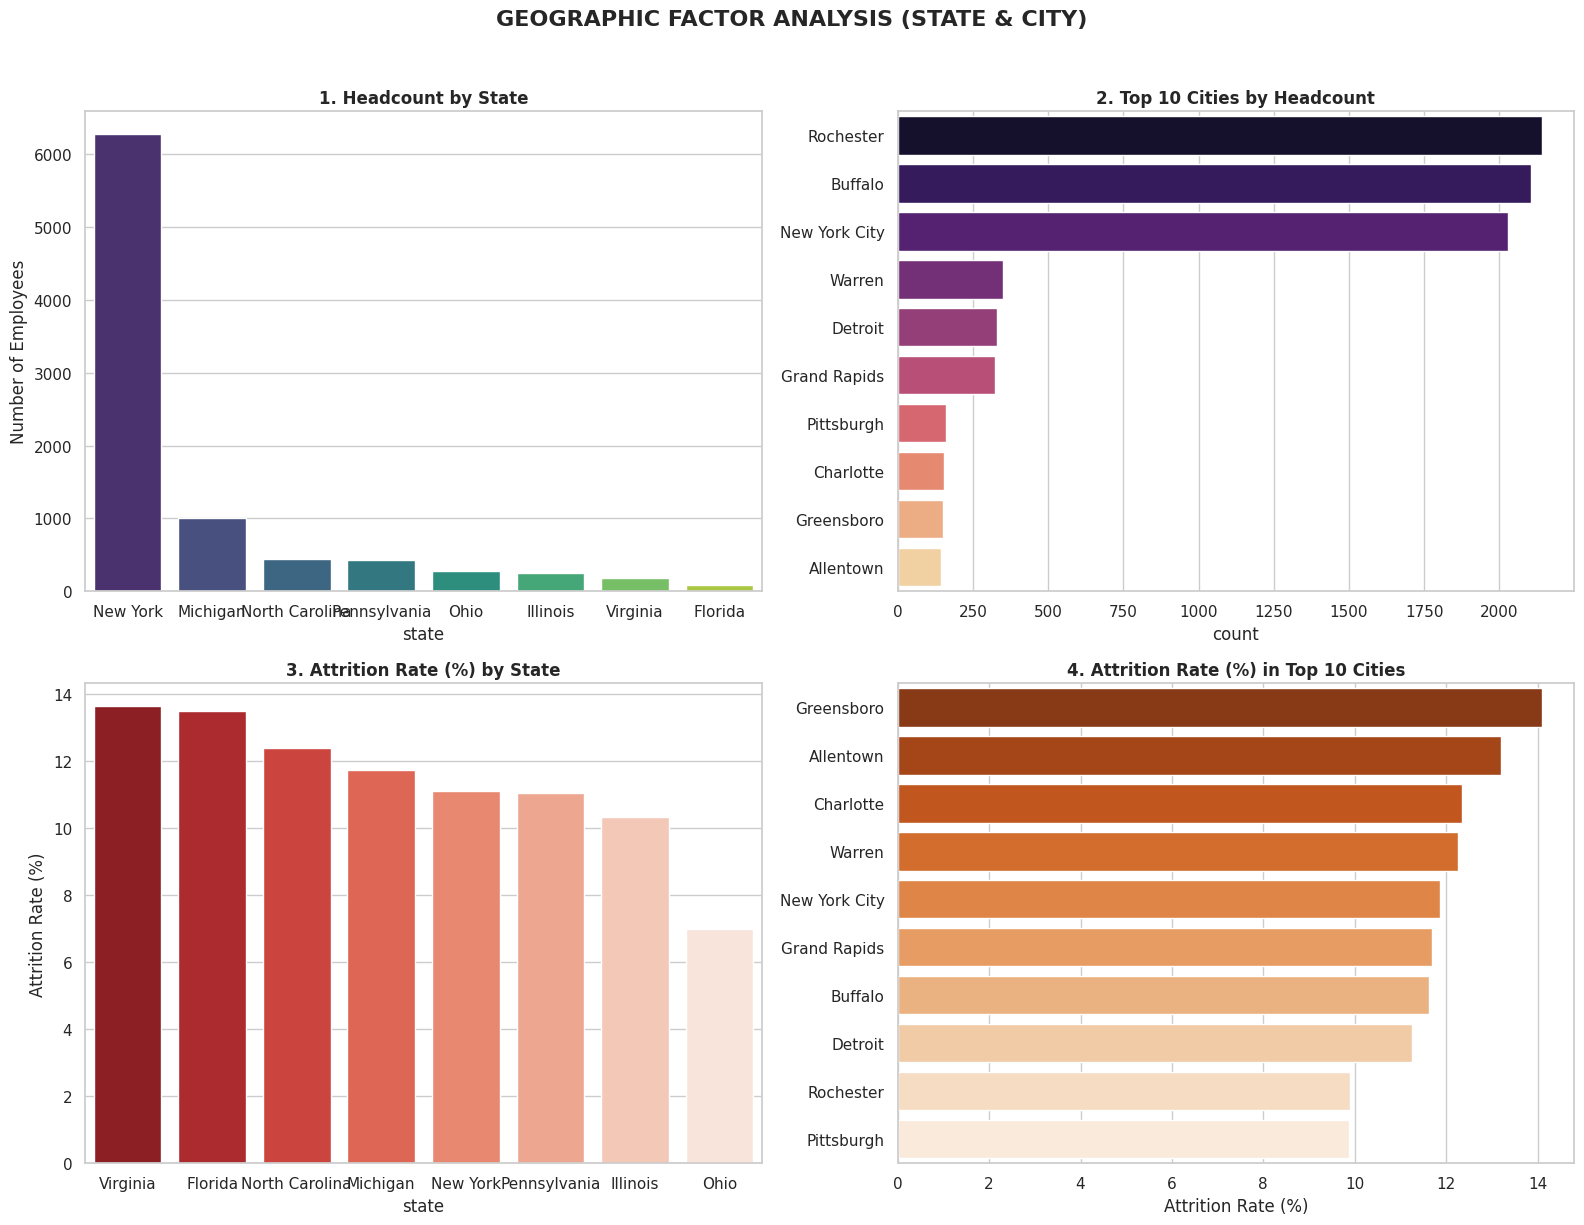

In [235]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Create a 2x2 grid for the Geographic Dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('GEOGRAPHIC FACTOR ANALYSIS (STATE & CITY)', fontsize=16, fontweight='bold', y=1.02)

# ==========================================
# ROW 1: UNIVARIATE (Personnel Distribution)
# ==========================================

# 1. Personnel distribution by State
sns.countplot(data=df, x='state', ax=axes[0, 0], palette='viridis', order=df['state'].value_counts().index)
axes[0, 0].set_title('1. Headcount by State', fontweight='bold')
axes[0, 0].set_ylabel('Number of Employees')

# 2. Personnel by City (Top 10)
top_10_cities = df['city'].value_counts().nlargest(10).index
sns.countplot(data=df[df['city'].isin(top_10_cities)], y='city', ax=axes[0, 1], palette='magma', order=top_10_cities)
axes[0, 1].set_title('2. Top 10 Cities by Headcount', fontweight='bold')
axes[0, 1].set_ylabel('')

# ==========================================
# ROW 2: BIVARIATE (Attrition Rate by Geography)
# ==========================================

# 3. Attrition Rate (%) by State
state_attrition = df.groupby('state')['attrition'].mean() * 100
state_attrition = state_attrition.sort_values(ascending=False)
sns.barplot(x=state_attrition.index, y=state_attrition.values, ax=axes[1, 0], palette='Reds_r')
axes[1, 0].set_title('3. Attrition Rate (%) by State', fontweight='bold')
axes[1, 0].set_ylabel('Attrition Rate (%)')

# 4. Attrition Rate (%) in Top 10 Cities
city_attrition = df[df['city'].isin(top_10_cities)].groupby('city')['attrition'].mean() * 100
city_attrition = city_attrition.sort_values(ascending=False)
sns.barplot(x=city_attrition.values, y=city_attrition.index, ax=axes[1, 1], palette='Oranges_r')
axes[1, 1].set_title('4. Attrition Rate (%) in Top 10 Cities', fontweight='bold')
axes[1, 1].set_xlabel('Attrition Rate (%)')
axes[1, 1].set_ylabel('')

plt.tight_layout()
plt.show()

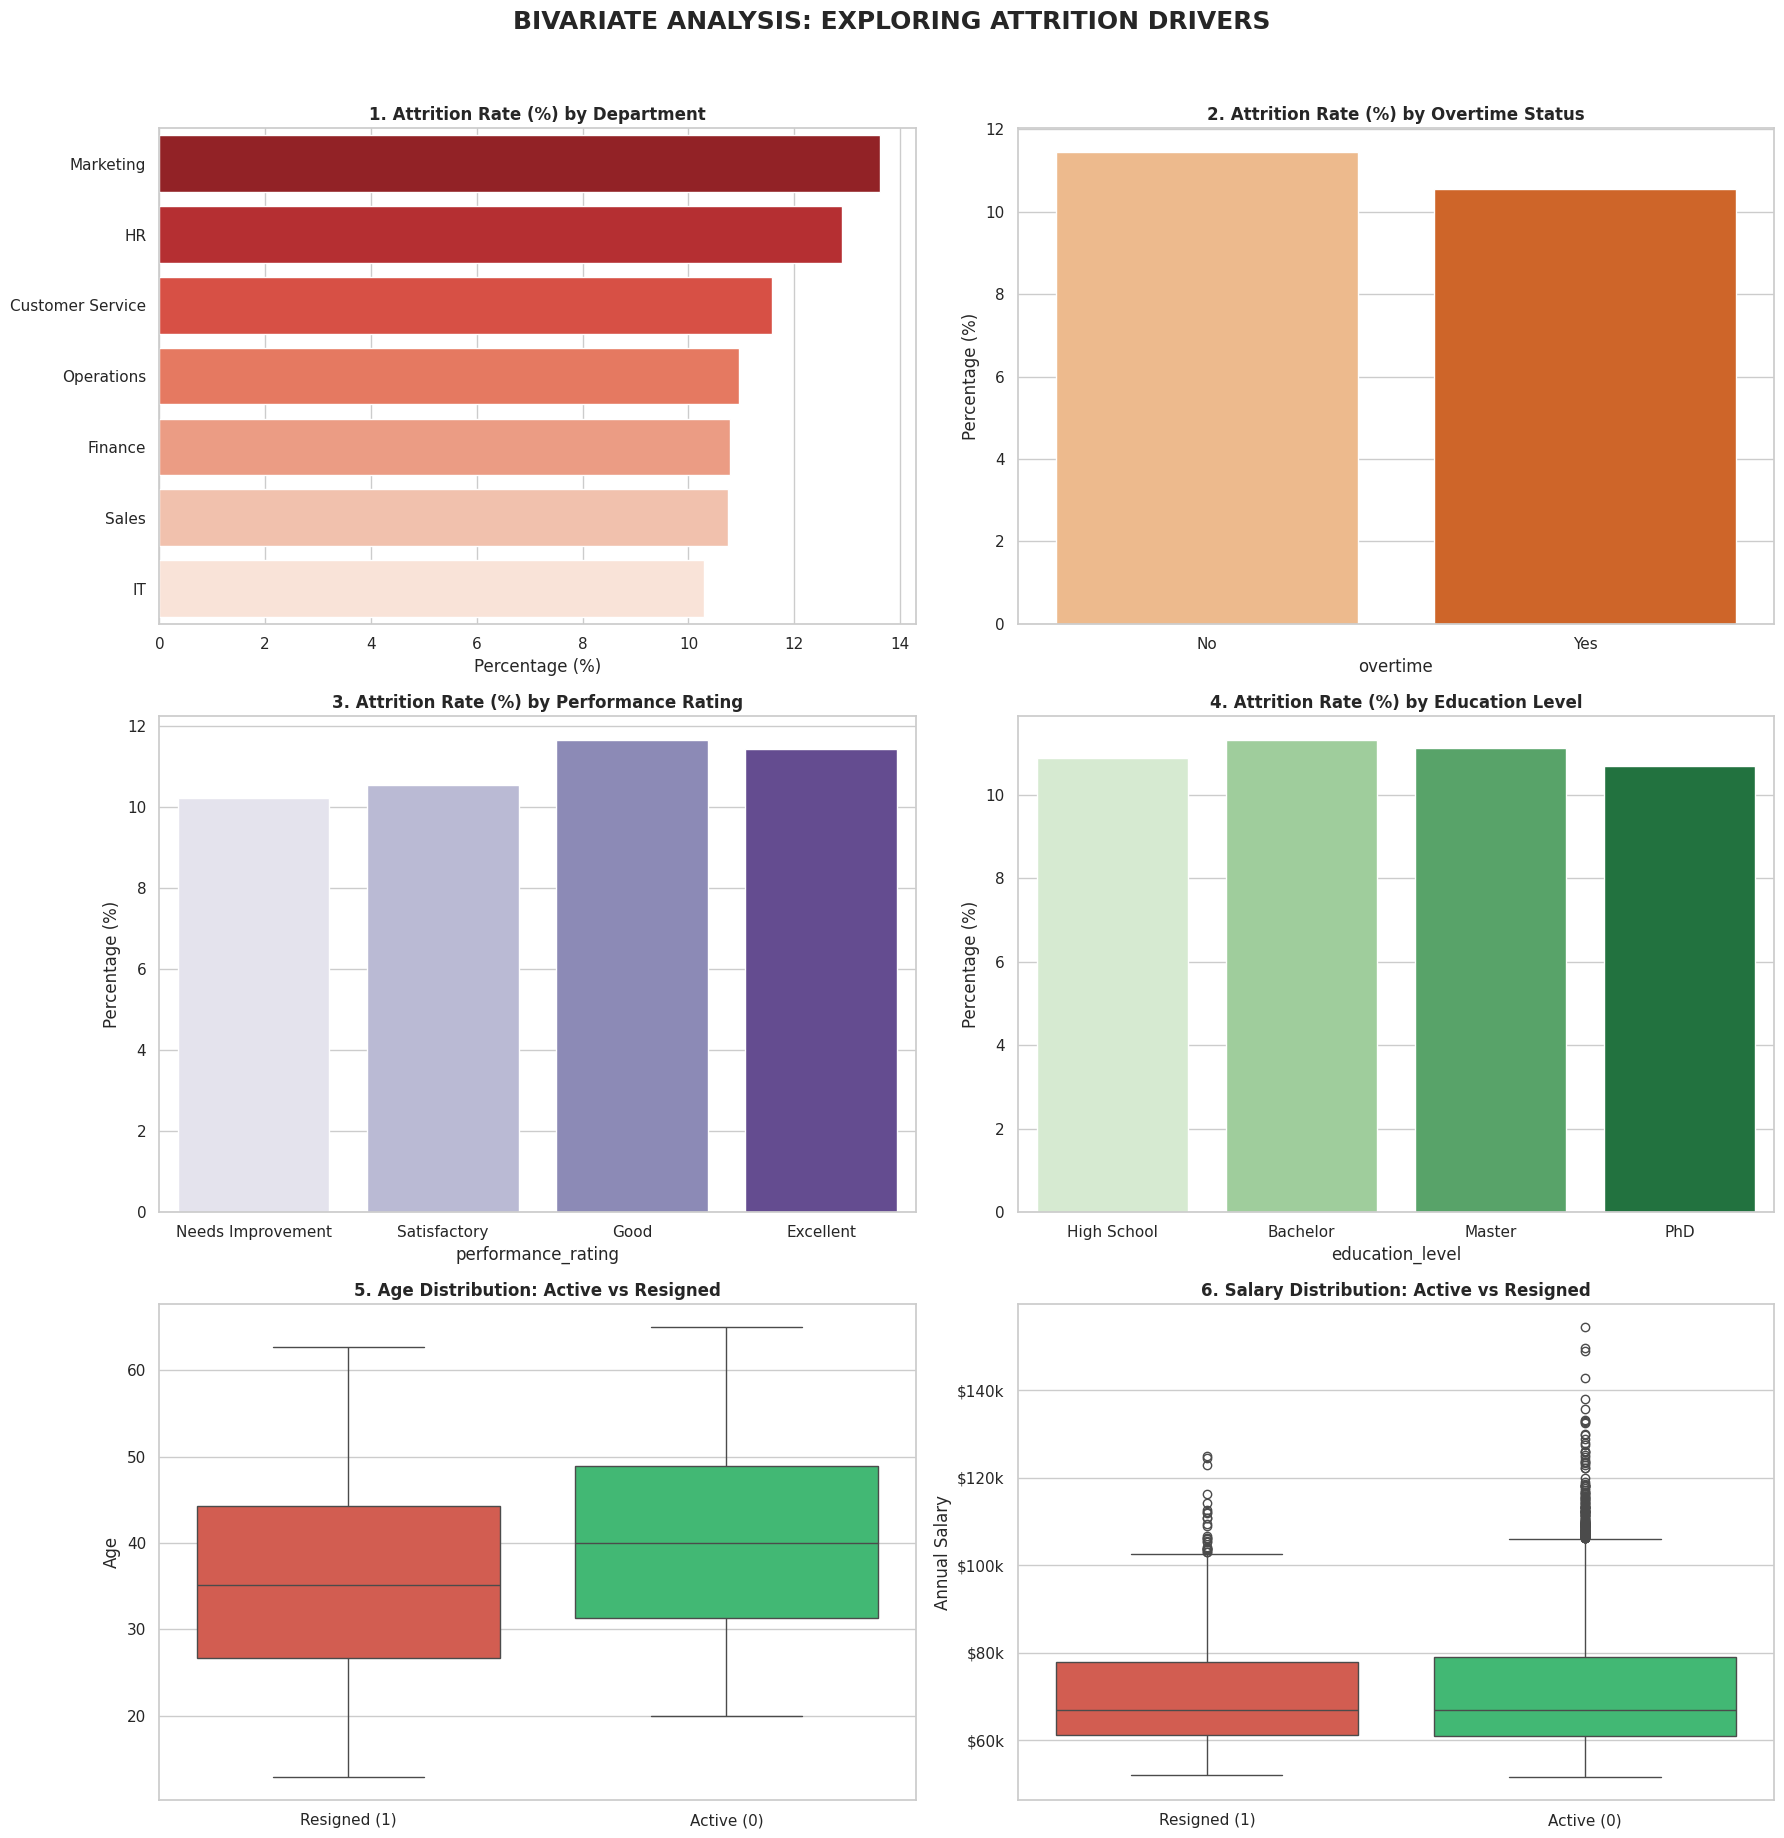

In [236]:

sns.set_theme(style="whitegrid")

# Initialize a 3x2 grid for 6 key bivariate charts
fig, axes = plt.subplots(3, 2, figsize=(18, 18))
fig.suptitle('BIVARIATE ANALYSIS: EXPLORING ATTRITION DRIVERS', fontsize=18, fontweight='bold', y=1.02)

# ==========================================
# GROUP 1: CATEGORICAL VARIABLES (Attrition Rate %)
# ==========================================

# 1. Attrition vs Department
dept_attrition = df_eda.groupby('department')['attrition'].mean() * 100
dept_attrition = dept_attrition.sort_values(ascending=False)
sns.barplot(x=dept_attrition.values, y=dept_attrition.index, ax=axes[0, 0], palette='Reds_r')
axes[0, 0].set_title('1. Attrition Rate (%) by Department', fontweight='bold')
axes[0, 0].set_xlabel('Percentage (%)')
axes[0, 0].set_ylabel('')

# 2. Attrition vs Overtime
ot_attrition = df_eda.groupby('overtime')['attrition'].mean() * 100
sns.barplot(x=ot_attrition.index, y=ot_attrition.values, ax=axes[0, 1], palette='Oranges')
axes[0, 1].set_title('2. Attrition Rate (%) by Overtime Status', fontweight='bold')
axes[0, 1].set_ylabel('Percentage (%)')

# 3. Attrition vs Performance Rating
perf_attrition = df_eda.groupby('performance_rating')['attrition'].mean() * 100
sns.barplot(x=perf_attrition.index, y=perf_attrition.values, ax=axes[1, 0], palette='Purples', order=['Needs Improvement', 'Satisfactory', 'Good', 'Excellent'])
axes[1, 0].set_title('3. Attrition Rate (%) by Performance Rating', fontweight='bold')
axes[1, 0].set_ylabel('Percentage (%)')

# 4. Attrition vs Education Level
edu_attrition = df_eda.groupby('education_level')['attrition'].mean() * 100
sns.barplot(x=edu_attrition.index, y=edu_attrition.values, ax=axes[1, 1], palette='Greens', order=['High School', 'Bachelor', 'Master', 'PhD'])
axes[1, 1].set_title('4. Attrition Rate (%) by Education Level', fontweight='bold')
axes[1, 1].set_ylabel('Percentage (%)')

# ==========================================
# GROUP 2: CONTINUOUS VARIABLES (Distribution comparison)
# ==========================================

# Map labels for cleaner visualization
df_viz = df_eda.copy()
df_viz['Attrition_Status'] = df_viz['attrition'].map({0: 'Active (0)', 1: 'Resigned (1)'})
box_palette = {'Active (0)': '#2ecc71', 'Resigned (1)': '#e74c3c'}

# 5. Attrition vs Age
sns.boxplot(data=df_viz, x='Attrition_Status', y='age', ax=axes[2, 0], palette=box_palette)
axes[2, 0].set_title('5. Age Distribution: Active vs Resigned', fontweight='bold')
axes[2, 0].set_xlabel('')
axes[2, 0].set_ylabel('Age')

# 6. Attrition vs Salary
sns.boxplot(data=df_viz, x='Attrition_Status', y='salary', ax=axes[2, 1], palette=box_palette)
axes[2, 1].set_title('6. Salary Distribution: Active vs Resigned', fontweight='bold')
axes[2, 1].set_xlabel('')
axes[2, 1].set_ylabel('Annual Salary')
axes[2, 1].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

plt.tight_layout()
plt.show()

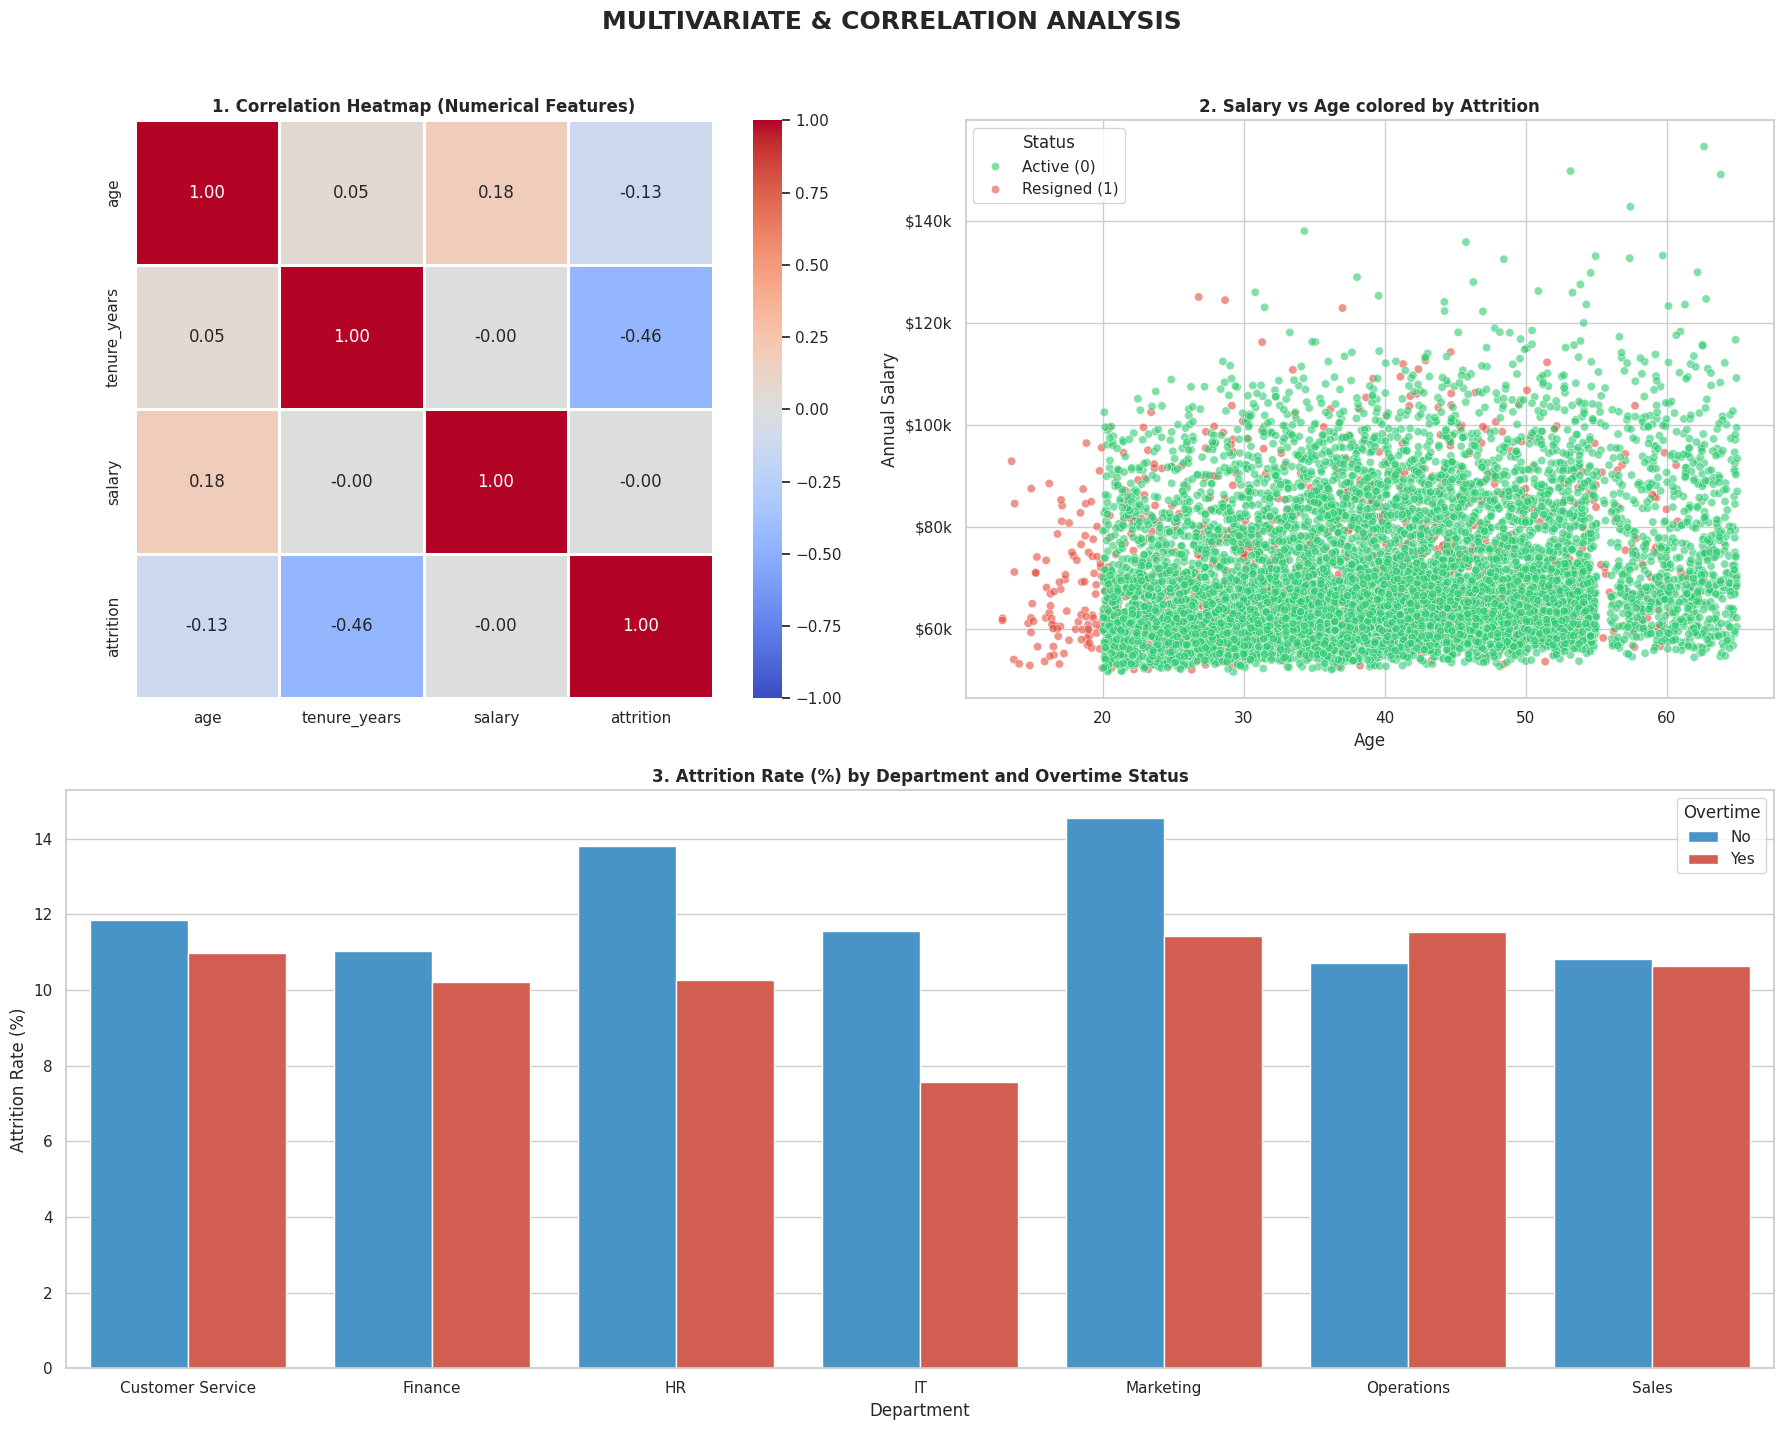

In [237]:

sns.set_theme(style="whitegrid")

# Create layout (Row 1: 2 columns, Row 2: 1 column spanning full width)
fig = plt.figure(figsize=(18, 14))
fig.suptitle('MULTIVARIATE & CORRELATION ANALYSIS', fontsize=18, fontweight='bold', y=1.02)

# ==========================================
# 1. CORRELATION HEATMAP
# ==========================================
ax1 = plt.subplot(2, 2, 1)
numeric_cols = ['age', 'tenure_years', 'salary', 'attrition']
corr_matrix = df_eda[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
            square=True, linewidths=1, ax=ax1, annot_kws={"size": 12})
ax1.set_title('1. Correlation Heatmap (Numerical Features)', fontweight='bold')

# ==========================================
# 2. MULTIVARIATE: SALARY vs AGE vs ATTRITION
# ==========================================
ax2 = plt.subplot(2, 2, 2)
sns.scatterplot(data=df_eda, x='age', y='salary', hue='attrition',
                palette=['#2ecc71', '#e74c3c'], alpha=0.6, ax=ax2)
ax2.set_title('2. Salary vs Age colored by Attrition', fontweight='bold')
ax2.set_xlabel('Age')
ax2.set_ylabel('Annual Salary')
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${int(x/1000)}k'))

# Update Legend
handles, labels = ax2.get_legend_handles_labels()
ax2.legend(handles=handles, labels=['Active (0)', 'Resigned (1)'], title='Status')

# ==========================================
# 3. MULTIVARIATE: DEPT vs OVERTIME vs ATTRITION RATE
# ==========================================
ax3 = plt.subplot(2, 1, 2)
dept_ot_attrition = df_eda.groupby(['department', 'overtime'])['attrition'].mean().reset_index()
dept_ot_attrition['attrition_pct'] = dept_ot_attrition['attrition'] * 100

sns.barplot(data=dept_ot_attrition, x='department', y='attrition_pct', hue='overtime',
            palette=['#3498db', '#e74c3c'], ax=ax3)
ax3.set_title('3. Attrition Rate (%) by Department and Overtime Status', fontweight='bold')
ax3.set_xlabel('Department')
ax3.set_ylabel('Attrition Rate (%)')
ax3.legend(title='Overtime')

plt.tight_layout()
plt.show()

### Data Distribution & Feature Selection Insights

*   **Univariate Analysis:** The `salary` feature is right-skewed, which is typical for income data. To handle this and the varying scales of other features, we will apply **StandardScaler** to ensure numerical stability during modeling.
*   **Bivariate Analysis:** There are no immediately obvious visual relationships between individual features and attrition. However, we have decided to **retain the 'State' feature**. Although its direct correlation is low, geographic location often acts as a proxy for regional economic factors and market-rate salary differences.
*   **Correlation Analysis:** Most features show near-zero or negative correlation coefficients. This indicates a lack of simple linear relationships, suggesting that a non-linear model like **XGBoost** is better suited to capture complex interaction patterns.

# Feature Engineering & Feature Selection

In [238]:
df_model = df_eda.copy()

In [239]:
# 1.1. Salary-to-Age Ratio
df_model['salary_to_age'] = df_model['salary'] / df_model['age']

# 1.2. Tenure-to-Age Ratio
# Avoid division by zero if age is missing or zero
df_model['tenure_to_age'] = df_model['tenure_years'] / (df_model['age'] + 1e-5)

# 1.3. Salary relative to Education Average
avg_salary_by_edu = df_model.groupby('education_level')['salary'].transform('mean')
df_model['salary_to_edu_avg'] = df_model['salary'] / avg_salary_by_edu

# ==========================================
# 2. CATEGORICAL ENCODING
# ==========================================

# 2.1. Ordinal Encoding (Ranked categories)
edu_mapping = {'High School': 1, 'Bachelor': 2, 'Master': 3, 'PhD': 4}
df_model['education_level'] = df_model['education_level'].map(edu_mapping)

perf_mapping = {'Needs Improvement': 1, 'Satisfactory': 2, 'Good': 3, 'Excellent': 4}
df_model['performance_rating'] = df_model['performance_rating'].map(perf_mapping)

# 2.2. Binary Encoding (Yes/No variables)
df_model['overtime'] = df_model['overtime'].map({'Yes': 1, 'No': 0})

# 2.3. One-Hot Encoding (Nominal variables)
# Includes Gender, Department, and State (re-introduced due to high attrition observed in certain regions).
cols_to_onehot = ['gender', 'department', 'state']
df_model = pd.get_dummies(df_model, columns=cols_to_onehot, drop_first=True, dtype=int)

# ==========================================
# 3. FINAL DATASET PREPARATION
# ==========================================

# Drop remaining text columns that are no longer needed (e.g., city)
df_model = df_model.drop(columns=['city','job_title'], errors='ignore')

print(f"Training dataset shape: {df_model.shape}")
print("\nFeatures included in the model:")
print(df_model.columns.tolist())

Training dataset shape: (8950, 24)

Features included in the model:
['education_level', 'salary', 'performance_rating', 'overtime', 'attrition', 'age', 'tenure_years', 'salary_to_age', 'tenure_to_age', 'salary_to_edu_avg', 'gender_Male', 'department_Finance', 'department_HR', 'department_IT', 'department_Marketing', 'department_Operations', 'department_Sales', 'state_Illinois', 'state_Michigan', 'state_New York', 'state_North Carolina', 'state_Ohio', 'state_Pennsylvania', 'state_Virginia']


In [240]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   education_level        8950 non-null   int64  
 1   salary                 8950 non-null   int64  
 2   performance_rating     8950 non-null   int64  
 3   overtime               8950 non-null   int64  
 4   attrition              8950 non-null   int64  
 5   age                    8950 non-null   float64
 6   tenure_years           8950 non-null   float64
 7   salary_to_age          8950 non-null   float64
 8   tenure_to_age          8950 non-null   float64
 9   salary_to_edu_avg      8950 non-null   float64
 10  gender_Male            8950 non-null   int64  
 11  department_Finance     8950 non-null   int64  
 12  department_HR          8950 non-null   int64  
 13  department_IT          8950 non-null   int64  
 14  department_Marketing   8950 non-null   int64  
 15  depa

In [241]:
df_model.head()

,education_level,salary,performance_rating,overtime,attrition,age,tenure_years,salary_to_age,tenure_to_age,salary_to_edu_avg,...,department_Marketing,department_Operations,department_Sales,state_Illinois,state_Michigan,state_New York,state_North Carolina,state_Ohio,state_Pennsylvania,state_Virginia
0,2,106044,3,0,1,42.283368,7.915127,2507.936480,0.187192,1.514746,...,0,0,1,0,0,0,0,0,1,0
1,2,65844,2,0,1,35.904175,1.741273,1833.881424,0.048498,0.940524,...,0,0,1,0,0,0,0,0,0,0
2,1,61316,3,0,1,49.902806,1.322382,1228.708454,0.026499,0.980695,...,1,0,0,0,0,1,0,0,0,0
3,2,90515,2,0,1,34.045175,7.310062,2658.673402,0.214716,1.292927,...,0,0,0,0,0,1,0,0,0,0
4,3,65570,3,0,1,43.893224,5.705681,1493.852451,0.129990,0.803700,...,0,0,0,0,0,1,0,0,0,0


# Modeling & Evaluation

In [242]:
import warnings
warnings.filterwarnings('ignore')

# 1. Separate Features (X) and Target (y) from df_model
X = df_model.drop(columns=['attrition'])
y = df_model['attrition']

# 2. Train-Test Split (80-20 split, using stratify to maintain attrition ratio)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. SMOTE Technique: Rebalance data (Apply to Train set only)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 4. Feature Scaling (Data normalization - Crucial for Logistic Regression)
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)

In [243]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "XGBoost": XGBClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42, eval_metric='logloss')
}

print("="*60)
print("BASELINE MODEL REPORT (Default Threshold = 0.5)")
print("="*60)

for name, model in models.items():
    # Training
    model.fit(X_train_smote_scaled, y_train_smote)

    # Prediction
    y_pred = model.predict(X_test_scaled)
    y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Display results
    print(f"\n✅ {name}")
    print(f"——— AUC-ROC: {roc_auc_score(y_test, y_pred_proba):.4f}")

    print("Detailed Classification Report:")
    print(classification_report(y_test, y_pred))
    print("-" * 60) # Visual separator between models

BASELINE MODEL REPORT (Default Threshold = 0.5)

✅ Logistic Regression
——— AUC-ROC: 0.8706
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      1590
           1       0.46      0.58      0.51       200

    accuracy                           0.88      1790
   macro avg       0.70      0.75      0.72      1790
weighted avg       0.89      0.88      0.88      1790

------------------------------------------------------------

✅ Decision Tree
——— AUC-ROC: 0.9073
Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.80      0.88      1590
           1       0.33      0.81      0.47       200

    accuracy                           0.80      1790
   macro avg       0.65      0.80      0.67      1790
weighted avg       0.90      0.80      0.83      1790

------------------------------------------------------------

✅ XGBoost
——— AUC-ROC: 0.9134
D

### Model Selection Analysis

Based on the baseline results of the three models at the default threshold (0.5), we can exclude Logistic Regression due to lower performance and compare the two top candidates: **Decision Tree** and **XGBoost**.

**1. Decision Tree Analysis :**
* **Strength:** Very high Recall (**81%**). The model captures most employees who are actually likely to leave.
* **Weakness:** Low Precision (**33%**). This means out of 3 alerts, 2 are false alarms, potentially leading to 'alert fatigue' for the HR team.

**2. XGBoost Analysis (The Balanced Approach):**
* **Predictive Power:** Highest **AUC-ROC (0.9134)**, showing superior ability to distinguish between groups.
* **Balance:** Default F1-Score of **0.70** with balanced Precision (**70%**) and Recall (**69%**).

**🏆 FINAL SELECTION:**
**XGBoost** is chosen as the core model. We will use **Threshold Tuning** to increase Recall while maintaining acceptable Precision.

In [244]:
from sklearn.model_selection import GridSearchCV

print("="*60)
print("FINE-TUNING XGBOOST (OPTIMIZING F1-SCORE FOR BALANCE)")
print("="*60)

# 1. Define search space
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'scale_pos_weight': [1, 2,3]
}

# 2. Setup GridSearchCV
grid_search_xgb = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid_xgb,
    scoring='recall',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# 3. Model Training
print("Running hyperparameter search...")
grid_search_xgb.fit(X_train_smote_scaled, y_train_smote)

# 4. Extract Best Model
best_xgb = grid_search_xgb.best_estimator_
print("\n✅ Optimal Parameters Found:", grid_search_xgb.best_params_)

y_pred_xgb = best_xgb.predict(X_test_scaled)
y_pred_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

print(f"\n——— AUC-ROC: {roc_auc_score(y_test, y_pred_proba_xgb):.4f}")
print("Classification Report (Default Threshold = 0.5):")
print(classification_report(y_test, y_pred_xgb))

RE-TUNING XGBOOST (OPTIMIZING F1-SCORE FOR BALANCE)
Running hyperparameter search...
Fitting 5 folds for each of 54 candidates, totalling 270 fits

✅ Optimal Parameters Found: {'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'scale_pos_weight': 3}

——— AUC-ROC: 0.9147
Classification Report (Default Threshold = 0.5):
              precision    recall  f1-score   support

           0       0.97      0.94      0.95      1590
           1       0.62      0.73      0.67       200

    accuracy                           0.92      1790
   macro avg       0.79      0.84      0.81      1790
weighted avg       0.93      0.92      0.92      1790



# Production & Export

In [249]:
import shap
import pandas as pd
import numpy as np

# Extend display limits
pd.set_option('display.max_colwidth', None)

print("="*70)
print("FINAL PRODUCT: ATTRITION RISK SCAN FOR ACTIVE EMPLOYEES")
print("="*70)

# 1. Prepare Data
df_active = df_model[df_model['attrition'] == 0].copy()
X_active = df_active.drop(columns=['attrition'])
X_active_scaled = scaler.transform(X_active)

# --- MODEL USAGE AREA ---
# Here we use the trained 'best_xgb' model to predict probabilities (0.0 to 1.0)
risk_scores = best_xgb.predict_proba(X_active_scaled)[:, 1]

# Use SHAP to explain the model's logic
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_active_scaled)
feature_names = X_active.columns.tolist()

# 2. FEATURE MAPPING & ACTION ENGINE
FEATURE_MAPPING = {
    'age': 'Age',
    'tenure_years': 'Tenure (Years)',
    'salary': 'Base Salary',
    'salary_to_age': 'Salary-to-Age Ratio',
    'tenure_to_age': 'Tenure-to-Age Ratio',
    'salary_to_edu_avg': 'Salary vs. Education Average',
    'overtime': 'Overtime History',
    'performance_rating': 'Performance Rating',
    'education_level': 'Education Level'
}

ACTION_MAPPING = {
    'salary': 'Review base salary against market benchmarks.',
    'salary_to_age': 'Check if salary aligns with age and experience level.',
    'salary_to_edu_avg': 'Review salary compared to their degree and department avg.',
    'overtime': 'Review workload to prevent burnout; reduce OT next week.',
    'tenure_to_age': 'Discuss career progression path; Identify if they feel "stuck".',
    'tenure_years': 'Discuss long-term retention plans and loyalty benefits.',
    'performance_rating': 'Align on performance expectations and recognition.',
}

def get_insights_and_actions(shap_array):
    top_indices = np.argsort(-shap_array)
    top_features = []
    primary_action = "Schedule a 1-on-1 stay interview."

    for idx in top_indices:
        if shap_array[idx] > 0:
            raw_name = feature_names[idx]
            translated_name = FEATURE_MAPPING.get(raw_name, raw_name.replace('_', ' ').title())
            top_features.append(translated_name)
            if len(top_features) == 1:
                if raw_name in ACTION_MAPPING:
                    primary_action = ACTION_MAPPING[raw_name]
        if len(top_features) == 3:
            break
    return " | ".join(top_features), primary_action

# 3. Apply insights
df_report = pd.DataFrame({'Risk_Score': risk_scores}, index=X_active.index)
df_report['Employee_ID'] = df.loc[X_active.index, 'employee_id']

results = [get_insights_and_actions(sv) for sv in shap_values]
df_report['Top_3_Risk_Factors'] = [res[0] for res in results]
df_report['Actionable_Advice'] = [res[1] for res in results]

# 4. Filter with the requested 0.5 threshold
final_threshold = 0.5
df_final = df_report[df_report['Risk_Score'] >= final_threshold].copy()
df_final = df_final.sort_values(by='Risk_Score', ascending=False)
df_final['Risk_Score'] = (df_final['Risk_Score'] * 100).round(1).astype(str) + '%'

df_final = df_final[['Employee_ID', 'Risk_Score', 'Top_3_Risk_Factors', 'Actionable_Advice']]
df_final.columns = ['Employee ID', 'Risk Score', 'Primary Risk Factors', 'Managerial Advice']

# 5. Export
csv_filename = "HR_Retention_Alerts_Default.csv"
df_final.to_csv(csv_filename, index=False, encoding='utf-8-sig')

print(f"\n✅ SUCCESS! Identified {len(df_final)} employees with Risk Score >= {final_threshold}.")
display(df_final.head(10))

FINAL PRODUCT: ATTRITION RISK SCAN FOR ACTIVE EMPLOYEES

✅ SUCCESS! Identified 330 employees with Risk Score >= 0.5.


,Employee ID,Risk Score,Primary Risk Factors,Managerial Advice
2564,00-49684512,98.3%,State New York | Base Salary | State Michigan,Schedule a 1-on-1 stay interview.
6214,00-40327888,98.2%,State New York | Base Salary | State Michigan,Schedule a 1-on-1 stay interview.
5067,00-87975659,95.7%,Education Level | Gender Male | Department Sales,Schedule a 1-on-1 stay interview.
3343,00-99369591,95.5%,Education Level | Gender Male | Department Sales,Schedule a 1-on-1 stay interview.
4108,00-82146810,95.2%,State New York | Base Salary | State Michigan,Schedule a 1-on-1 stay interview.
5044,00-93853635,94.7%,State New York | State Michigan | Education Level,Schedule a 1-on-1 stay interview.
2122,00-82509424,94.5%,Salary vs. Education Average | Age | Department Sales,Review salary compared to their degree and department avg.
3717,00-96853189,94.1%,State New York | Base Salary | State Michigan,Schedule a 1-on-1 stay interview.
7391,00-53827193,93.5%,State New York | Base Salary | State Michigan,Schedule a 1-on-1 stay interview.
8048,00-95901983,91.2%,Base Salary | State New York | State Michigan,Review base salary against market benchmarks.


In [250]:
df_final

,Employee ID,Risk Score,Primary Risk Factors,Managerial Advice
2564,00-49684512,98.3%,State New York | Base Salary | State Michigan,Schedule a 1-on-1 stay interview.
6214,00-40327888,98.2%,State New York | Base Salary | State Michigan,Schedule a 1-on-1 stay interview.
5067,00-87975659,95.7%,Education Level | Gender Male | Department Sales,Schedule a 1-on-1 stay interview.
3343,00-99369591,95.5%,Education Level | Gender Male | Department Sales,Schedule a 1-on-1 stay interview.
4108,00-82146810,95.2%,State New York | Base Salary | State Michigan,Schedule a 1-on-1 stay interview.
...,...,...,...,...
3412,00-72024691,50.2%,State New York | Salary vs. Education Average | State Michigan,Schedule a 1-on-1 stay interview.
8566,00-86434517,50.2%,State New York | Salary vs. Education Average | Department Operations,Schedule a 1-on-1 stay interview.
5922,00-33946564,50.1%,Department Operations | Tenure-to-Age Ratio | Department Sales,Schedule a 1-on-1 stay interview.
6735,00-90969675,50.0%,Base Salary | Department Operations | Department Sales,Review base salary against market benchmarks.
